# GP Likelihood From Peak Forces, Option 2

This notebook treats the two angular velocities as separate observables.

Inputs to the GP:

- `phi_deg`
- `cohesion_kPa`

Outputs/observables:

- `Fz_peak_N_omega10`
- `Fx_peak_N_omega10`
- `Fz_peak_N_omega15`
- `Fx_peak_N_omega15`

**Important:** This notebook builds **one combined likelihood map** using both angular velocities together. The plotted likelihood is:

```text
log L(phi, c | omega=10 peak forces AND omega=15 peak forces)
```

It does **not** create two separate likelihood maps for omega=10 and omega=15. In this Option 2 setup, omega-specific peak forces are treated as separate observables and their log-likelihood contributions are summed into one joint map.

## Validation Setup

The coarse grid data are used for GP training. The four midpoint soil cases are held out for validation:

- `phi=17.5 deg, c=7.5 kPa`
- `phi=17.5 deg, c=17.5 kPa`
- `phi=27.5 deg, c=7.5 kPa`
- `phi=27.5 deg, c=17.5 kPa`

Each validation point includes both `omega=10` and `omega=15` peak forces. The notebook predicts those held-out peak forces and reports absolute and relative errors.

This version uses only `csv`, `json`, `numpy`, and `matplotlib`; no pandas/sklearn/scipy are required.


In [1]:
from pathlib import Path
import csv
import json

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COARSE_CSV = ROOT / "data" / "synthetic_data" / "cohesion_phi_omega_force_sweep" / "force_sweep_summary.csv"
MIDPOINT_CSV = ROOT / "data" / "synthetic_data" / "cohesion_phi_omega_force_sweep_midpoints" / "force_sweep_summary.csv"
OUT_DIR = ROOT / "data" / "synthetic_data" / "gp_peak_force_option2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Coarse CSV: {COARSE_CSV}")
print(f"Midpoint CSV: {MIDPOINT_CSV if MIDPOINT_CSV.exists() else 'not found'}")
print(f"Output dir: {OUT_DIR}")
# Set SHOW_FIGURES=False before executing this notebook in batch tests.
SHOW_FIGURES = globals().get("SHOW_FIGURES", True)


Coarse CSV: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_omega_force_sweep/force_sweep_summary.csv
Midpoint CSV: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/cohesion_phi_omega_force_sweep_midpoints/force_sweep_summary.csv
Output dir: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2


In [2]:
def read_sweep_csv(path, source_name):
    rows = []
    with path.open(newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append({
                "phi_deg": float(row["phi_deg"]),
                "cohesion_kPa": float(row["cohesion_kPa"]),
                "cohesion_Pa": float(row["cohesion_Pa"]),
                "omega_rad_s": float(row["omega_rad_s"]),
                "Fz_peak_N": float(row["Fz_peak_N"]),
                "Fx_peak_N": float(row["Fx_peak_N"]),
                "source": source_name,
            })
    return rows

train_rows = read_sweep_csv(COARSE_CSV, "coarse_train")
validation_rows = read_sweep_csv(MIDPOINT_CSV, "midpoint_validation") if MIDPOINT_CSV.exists() else []

train_rows = sorted(train_rows, key=lambda r: (r["cohesion_kPa"], r["phi_deg"], r["omega_rad_s"]))
validation_rows = sorted(validation_rows, key=lambda r: (r["cohesion_kPa"], r["phi_deg"], r["omega_rad_s"]))

print(f"Training raw rows: {len(train_rows)}")
print(f"Validation raw rows: {len(validation_rows)}")
print("First training rows:")
for row in train_rows[:4]:
    print(row)
print("First validation rows:")
for row in validation_rows[:4]:
    print(row)


Training raw rows: 72
Validation raw rows: 8
First training rows:
{'phi_deg': 10.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'omega_rad_s': 10.0, 'Fz_peak_N': 85.44217661737765, 'Fx_peak_N': 124.82012764154376, 'source': 'coarse_train'}
{'phi_deg': 10.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'omega_rad_s': 15.0, 'Fz_peak_N': 121.23311538808157, 'Fx_peak_N': 184.49600613771372, 'source': 'coarse_train'}
{'phi_deg': 15.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'omega_rad_s': 10.0, 'Fz_peak_N': 87.4176043759988, 'Fx_peak_N': 128.91780026880525, 'source': 'coarse_train'}
{'phi_deg': 15.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'omega_rad_s': 15.0, 'Fz_peak_N': 123.58424651182376, 'Fx_peak_N': 188.91111149548342, 'source': 'coarse_train'}
First validation rows:
{'phi_deg': 17.5, 'cohesion_kPa': 7.5, 'cohesion_Pa': 7500.0, 'omega_rad_s': 10.0, 'Fz_peak_N': 119.44383627879887, 'Fx_peak_N': 206.6607494579107, 'source': 'midpoint_validation'}
{'phi_deg': 17.5, 'cohesion_kPa': 7.5, 'cohes

In [3]:
OMEGAS = [10.0, 15.0]
OBS_COLS = [
    "Fz_peak_N_omega10",
    "Fx_peak_N_omega10",
    "Fz_peak_N_omega15",
    "Fx_peak_N_omega15",
]


def pivot_two_omega_observables(rows):
    grouped = {}
    for row in rows:
        key = (row["phi_deg"], row["cohesion_kPa"])
        grouped.setdefault(key, {
            "phi_deg": row["phi_deg"],
            "cohesion_kPa": row["cohesion_kPa"],
            "cohesion_Pa": row["cohesion_Pa"],
        })
        omega_token = int(round(row["omega_rad_s"]))
        grouped[key][f"Fz_peak_N_omega{omega_token:02d}"] = row["Fz_peak_N"]
        grouped[key][f"Fx_peak_N_omega{omega_token:02d}"] = row["Fx_peak_N"]

    wide = []
    for item in grouped.values():
        if all(col in item for col in OBS_COLS):
            wide.append(item)
    return sorted(wide, key=lambda r: (r["cohesion_kPa"], r["phi_deg"]))

wide_train = pivot_two_omega_observables(train_rows)
wide_val = pivot_two_omega_observables(validation_rows)

print(f"Wide GP training rows: {len(wide_train)}")
print(f"Wide validation rows: {len(wide_val)}")
print("Observables:", OBS_COLS)
print("Training examples:")
for row in wide_train[:4]:
    print(row)
print("Validation examples:")
for row in wide_val[:4]:
    print(row)


Wide GP training rows: 36
Wide validation rows: 4
Observables: ['Fz_peak_N_omega10', 'Fx_peak_N_omega10', 'Fz_peak_N_omega15', 'Fx_peak_N_omega15']
Training examples:
{'phi_deg': 10.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'Fz_peak_N_omega10': 85.44217661737765, 'Fx_peak_N_omega10': 124.82012764154376, 'Fz_peak_N_omega15': 121.23311538808157, 'Fx_peak_N_omega15': 184.49600613771372}
{'phi_deg': 15.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'Fz_peak_N_omega10': 87.4176043759988, 'Fx_peak_N_omega10': 128.91780026880525, 'Fz_peak_N_omega15': 123.58424651182376, 'Fx_peak_N_omega15': 188.91111149548342}
{'phi_deg': 20.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'Fz_peak_N_omega10': 89.96270887859907, 'Fx_peak_N_omega10': 133.27161020186517, 'Fz_peak_N_omega15': 126.71437141297014, 'Fx_peak_N_omega15': 194.3112200747944}
{'phi_deg': 25.0, 'cohesion_kPa': 0.0, 'cohesion_Pa': 0.0, 'Fz_peak_N_omega10': 93.08059843402748, 'Fx_peak_N_omega10': 138.6491506341325, 'Fz_peak_N_omega15': 130.06086

In [4]:
X_raw = np.array([[r["phi_deg"], r["cohesion_kPa"]] for r in wide_train], dtype=float)
Y_raw = np.array([[r[col] for col in OBS_COLS] for r in wide_train], dtype=float)

x_mean = X_raw.mean(axis=0)
x_std = X_raw.std(axis=0)
x_std[x_std == 0.0] = 1.0
X = (X_raw - x_mean) / x_std

y_mean = Y_raw.mean(axis=0)
y_std = Y_raw.std(axis=0)
y_std[y_std == 0.0] = 1.0
Y = (Y_raw - y_mean) / y_std

print("X mean:", x_mean)
print("X std :", x_std)
print("Y mean:", y_mean)
print("Y std :", y_std)


X mean: [22.5 12.5]
X std : [8.53912564 8.53912564]
Y mean: [118.91252058 205.80640605 154.92058089 263.24926304]
Y std : [13.1379239  33.00589131 13.10138985 31.40151268]


In [5]:
def rbf_kernel(A, B, length_scale=0.8, amplitude=1.0):
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    diff = A[:, None, :] - B[None, :, :]
    sqdist = np.sum((diff / length_scale) ** 2, axis=2)
    return amplitude**2 * np.exp(-0.5 * sqdist)


def train_fixed_rbf_gp(X, y, length_scale=0.9, amplitude=1.0, noise=1e-5):
    K = rbf_kernel(X, X, length_scale=length_scale, amplitude=amplitude)
    K = K + (noise**2 + 1e-10) * np.eye(len(X))
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return {
        "X": X.copy(),
        "y": y.copy(),
        "length_scale": float(length_scale),
        "amplitude": float(amplitude),
        "noise": float(noise),
        "L": L,
        "alpha": alpha,
    }


def predict_fixed_rbf_gp(model, X_star):
    X_star = np.atleast_2d(np.asarray(X_star, dtype=float))
    K_star = rbf_kernel(X_star, model["X"], model["length_scale"], model["amplitude"])
    mean = K_star @ model["alpha"]
    v = np.linalg.solve(model["L"], K_star.T)
    var = model["amplitude"]**2 - np.sum(v * v, axis=0)
    var = np.maximum(var, 1e-12)
    return mean, np.sqrt(var)


gps = []
for k, col in enumerate(OBS_COLS):
    model = train_fixed_rbf_gp(X, Y[:, k], length_scale=0.9, amplitude=1.0, noise=1e-4)
    gps.append(model)
    print(f"Trained fixed-RBF GP for {col}")

Trained fixed-RBF GP for Fz_peak_N_omega10
Trained fixed-RBF GP for Fx_peak_N_omega10
Trained fixed-RBF GP for Fz_peak_N_omega15
Trained fixed-RBF GP for Fx_peak_N_omega15


In [6]:
def standardize_x(phi_deg, cohesion_kpa):
    return (np.array([[phi_deg, cohesion_kpa]], dtype=float) - x_mean) / x_std


def gp_predict_observables(phi_deg, cohesion_kpa, return_std=True):
    x_star = standardize_x(phi_deg, cohesion_kpa)
    pred = {}
    for k, (col, model) in enumerate(zip(OBS_COLS, gps)):
        mu_std, sigma_std = predict_fixed_rbf_gp(model, x_star)
        mu = float(mu_std[0] * y_std[k] + y_mean[k])
        sigma = float(sigma_std[0] * y_std[k])
        pred[col] = (mu, sigma) if return_std else mu
    return pred


def gp_log_likelihood(phi_deg, cohesion_kpa, obs_dict, obs_noise_rel=0.05, min_noise=1e-6):
    """Gaussian likelihood for observed peak-force summaries."""
    pred = gp_predict_observables(phi_deg, cohesion_kpa, return_std=True)
    ll = 0.0
    for col in OBS_COLS:
        if col not in obs_dict:
            continue
        mu, gp_sigma = pred[col]
        obs = float(obs_dict[col])
        meas_sigma = max(obs_noise_rel * abs(obs), min_noise)
        total_var = gp_sigma**2 + meas_sigma**2
        ll += -0.5 * (obs - mu)**2 / total_var - 0.5 * np.log(2.0 * np.pi * total_var)
    return float(ll)


# Use all four midpoint validation points as demo observations if available.
demo_rows = wide_val if wide_val else [wide_train[0]]
demo_cases = []
for row in demo_rows:
    obs = {col: float(row[col]) for col in OBS_COLS}
    phi = float(row["phi_deg"])
    coh = float(row["cohesion_kPa"])
    demo_cases.append({"phi_deg": phi, "cohesion_kPa": coh, "obs": obs})

print(f"Demo observation points: {len(demo_cases)}")
for case in demo_cases:
    pred = gp_predict_observables(case["phi_deg"], case["cohesion_kPa"], return_std=False)
    print(f"  phi={case['phi_deg']:g} deg, c={case['cohesion_kPa']:g} kPa, "
          f"logL={gp_log_likelihood(case['phi_deg'], case['cohesion_kPa'], case['obs']):.3f}")
    print("    observed:", json.dumps(case["obs"], indent=2))
    print("    predicted:", json.dumps(pred, indent=2))


Demo observation points: 4
  phi=17.5 deg, c=7.5 kPa, logL=-12.454
    observed: {
  "Fz_peak_N_omega10": 119.44383627879887,
  "Fx_peak_N_omega10": 206.6607494579107,
  "Fz_peak_N_omega15": 154.41370407822288,
  "Fx_peak_N_omega15": 264.32769942910943
}
    predicted: {
  "Fz_peak_N_omega10": 119.85275724129109,
  "Fx_peak_N_omega10": 208.70876373636446,
  "Fz_peak_N_omega15": 154.78313406023616,
  "Fx_peak_N_omega15": 265.5896611261612
}
  phi=27.5 deg, c=7.5 kPa, logL=-12.526
    observed: {
  "Fz_peak_N_omega10": 120.09743336317852,
  "Fx_peak_N_omega10": 213.88719772550684,
  "Fz_peak_N_omega15": 156.3817030615974,
  "Fx_peak_N_omega15": 271.3344421212663
}
    predicted: {
  "Fz_peak_N_omega10": 120.79264432340202,
  "Fx_peak_N_omega10": 215.45354106488443,
  "Fz_peak_N_omega15": 156.70300608631223,
  "Fx_peak_N_omega15": 272.42644876731845
}
  phi=17.5 deg, c=17.5 kPa, logL=-12.721
    observed: {
  "Fz_peak_N_omega10": 126.3772499489008,
  "Fx_peak_N_omega10": 226.957226523741,

## Midpoint Validation

The following cells use the four midpoint cases as held-out validation points. The GP was trained only on the coarse grid.


In [7]:
validation_results = []
for row in wide_val:
    phi = float(row["phi_deg"])
    coh = float(row["cohesion_kPa"])
    pred = gp_predict_observables(phi, coh, return_std=True)
    for col in OBS_COLS:
        true = float(row[col])
        mu, sigma = pred[col]
        abs_err = mu - true
        rel_err_pct = 100.0 * abs_err / (abs(true) + 1e-12)
        validation_results.append({
            "phi_deg": phi,
            "cohesion_kPa": coh,
            "observable": col,
            "true_N": true,
            "pred_N": mu,
            "pred_sigma_N": sigma,
            "abs_error_N": abs_err,
            "rel_error_pct": rel_err_pct,
        })

print(f"Validation rows: {len(validation_results)}")
for r in validation_results[:8]:
    print(
        f"phi={r['phi_deg']:4.1f}, c={r['cohesion_kPa']:4.1f} kPa, "
        f"{r['observable']}: true={r['true_N']:.3f}, pred={r['pred_N']:.3f}, "
        f"err={r['abs_error_N']:+.3f} N ({r['rel_error_pct']:+.2f}%)"
    )

print()
print("Mean absolute relative error by observable:")
for col in OBS_COLS:
    vals = [abs(r["rel_error_pct"]) for r in validation_results if r["observable"] == col]
    print(f"  {col}: {np.mean(vals):.2f}%")


Validation rows: 16
phi=17.5, c= 7.5 kPa, Fz_peak_N_omega10: true=119.444, pred=119.853, err=+0.409 N (+0.34%)
phi=17.5, c= 7.5 kPa, Fx_peak_N_omega10: true=206.661, pred=208.709, err=+2.048 N (+0.99%)
phi=17.5, c= 7.5 kPa, Fz_peak_N_omega15: true=154.414, pred=154.783, err=+0.369 N (+0.24%)
phi=17.5, c= 7.5 kPa, Fx_peak_N_omega15: true=264.328, pred=265.590, err=+1.262 N (+0.48%)
phi=27.5, c= 7.5 kPa, Fz_peak_N_omega10: true=120.097, pred=120.793, err=+0.695 N (+0.58%)
phi=27.5, c= 7.5 kPa, Fx_peak_N_omega10: true=213.887, pred=215.454, err=+1.566 N (+0.73%)
phi=27.5, c= 7.5 kPa, Fz_peak_N_omega15: true=156.382, pred=156.703, err=+0.321 N (+0.21%)
phi=27.5, c= 7.5 kPa, Fx_peak_N_omega15: true=271.334, pred=272.426, err=+1.092 N (+0.40%)

Mean absolute relative error by observable:
  Fz_peak_N_omega10: 0.54%
  Fx_peak_N_omega10: 0.66%
  Fz_peak_N_omega15: 0.16%
  Fx_peak_N_omega15: 0.36%


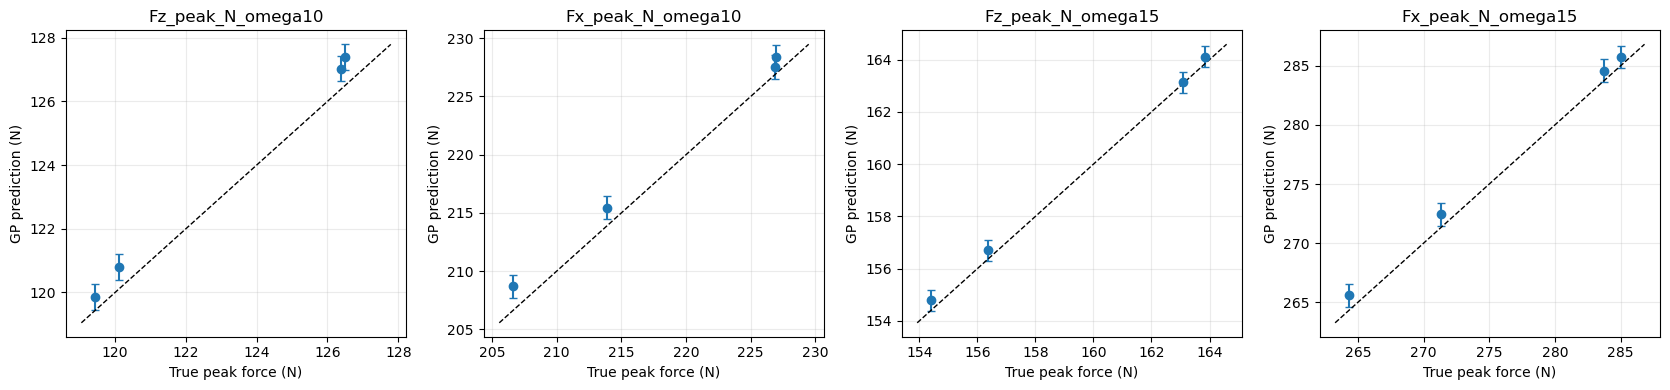

Saved: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2/midpoint_validation_pred_vs_true.png


In [8]:
fig, axes = plt.subplots(1, len(OBS_COLS), figsize=(4.2 * len(OBS_COLS), 4), squeeze=False)
axes = axes[0]

for ax, col in zip(axes, OBS_COLS):
    subset = [r for r in validation_results if r["observable"] == col]
    true = np.array([r["true_N"] for r in subset])
    pred = np.array([r["pred_N"] for r in subset])
    sig = np.array([r["pred_sigma_N"] for r in subset])
    ax.errorbar(true, pred, yerr=2.0 * sig, fmt="o", capsize=3)
    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    pad = 0.05 * (hi - lo + 1e-12)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1)
    ax.set_title(col)
    ax.set_xlabel("True peak force (N)")
    ax.set_ylabel("GP prediction (N)")
    ax.grid(True, alpha=0.25)

plt.tight_layout()
val_fig_path = OUT_DIR / "midpoint_validation_pred_vs_true.png"
plt.savefig(val_fig_path, dpi=180, bbox_inches="tight")
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)
print(f"Saved: {val_fig_path}")


In [9]:
phi_grid = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 80)
c_grid = np.linspace(X_raw[:, 1].min(), X_raw[:, 1].max(), 80)

demo_surfaces = []
for case in demo_cases:
    LL = np.empty((len(c_grid), len(phi_grid)))
    for i, c_val in enumerate(c_grid):
        for j, phi_val in enumerate(phi_grid):
            LL[i, j] = gp_log_likelihood(phi_val, c_val, case["obs"])

    LL_rel = LL - np.nanmax(LL)
    imax, jmax = np.unravel_index(np.nanargmax(LL), LL.shape)
    map_phi = float(phi_grid[jmax])
    map_c = float(c_grid[imax])
    demo_surfaces.append({
        "case": case,
        "LL_rel": LL_rel,
        "map_phi": map_phi,
        "map_c": map_c,
    })
    print(
        f"Demo likelihood MAP for phi={case['phi_deg']:.1f}, c={case['cohesion_kPa']:.1f} kPa: "
        f"phi={map_phi:.2f} deg, c={map_c:.2f} kPa"
    )


Demo likelihood MAP for phi=17.5, c=7.5 kPa: phi=16.33 deg, c=7.28 kPa
Demo likelihood MAP for phi=27.5, c=7.5 kPa: phi=29.62 deg, c=6.96 kPa
Demo likelihood MAP for phi=17.5, c=17.5 kPa: phi=24.56 deg, c=15.82 kPa
Demo likelihood MAP for phi=27.5, c=17.5 kPa: phi=29.94 deg, c=16.14 kPa


/var/folders/jq/khx6mlw900l3dzqh_x5_9v540000gn/T/ipykernel_37850/605545002.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 0.98])


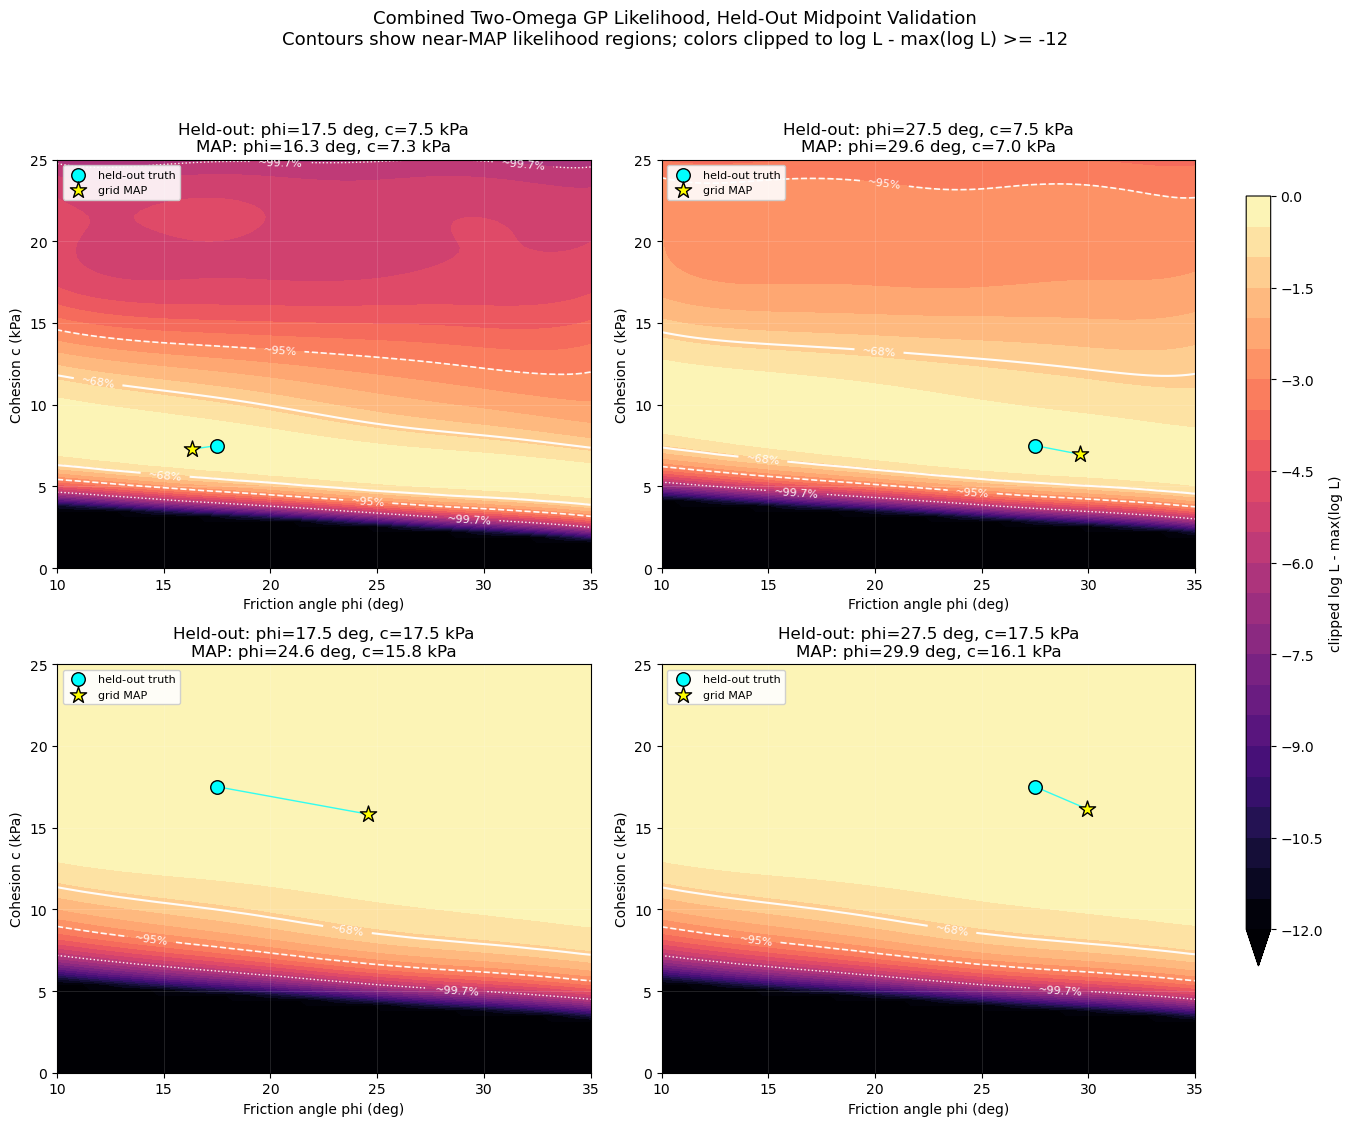

Saved: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2/demo_likelihood_surfaces_all_midpoints_contours.png


In [10]:
# Clearer likelihood visualization.
# Relative log-likelihood can have a very large dynamic range, so this plot clips
# to a useful near-MAP range and overlays contour lines.  For 2 parameters,
# log-likelihood drops of about 1.15, 3.0, and 5.99 correspond roughly to
# 68%, 95%, and 99.7% confidence regions when the likelihood is Gaussian.

n_cases = len(demo_surfaces)
n_cols = 2 if n_cases > 1 else 1
n_rows = int(np.ceil(n_cases / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.8 * n_cols, 5.5 * n_rows), squeeze=False)
axes_flat = axes.ravel()

clip_min = -12.0
filled_levels = np.linspace(clip_min, 0.0, 25)
contour_levels = [-5.99, -3.0, -1.15]
contour_labels = {
    -1.15: "~68%",
    -3.0: "~95%",
    -5.99: "~99.7%",
}

for ax, surf in zip(axes_flat, demo_surfaces):
    case = surf["case"]
    LL_plot = np.maximum(surf["LL_rel"], clip_min)

    cf = ax.contourf(
        phi_grid,
        c_grid,
        LL_plot,
        levels=filled_levels,
        cmap="magma",
        extend="min",
    )
    cs = ax.contour(
        phi_grid,
        c_grid,
        surf["LL_rel"],
        levels=contour_levels,
        colors="white",
        linewidths=[1.0, 1.2, 1.5],
        alpha=0.95,
        linestyles=[":", "--", "-"],
    )
    ax.clabel(
        cs,
        fmt={level: contour_labels[level] for level in contour_levels},
        fontsize=8,
        inline=True,
    )

    ax.scatter(
        [case["phi_deg"]], [case["cohesion_kPa"]],
        c="cyan", edgecolor="black", s=95, marker="o", label="held-out truth", zorder=5
    )
    ax.scatter(
        [surf["map_phi"]], [surf["map_c"]],
        c="yellow", edgecolor="black", marker="*", s=150, label="grid MAP", zorder=6
    )
    ax.plot(
        [case["phi_deg"], surf["map_phi"]],
        [case["cohesion_kPa"], surf["map_c"]],
        color="cyan", lw=1.0, alpha=0.8, zorder=4,
    )

    ax.set_xlabel("Friction angle phi (deg)")
    ax.set_ylabel("Cohesion c (kPa)")
    ax.set_title(
        f"Held-out: phi={case['phi_deg']:.1f} deg, c={case['cohesion_kPa']:.1f} kPa\n"
        f"MAP: phi={surf['map_phi']:.1f} deg, c={surf['map_c']:.1f} kPa"
    )
    ax.grid(True, color="white", alpha=0.15, lw=0.6)
    ax.legend(framealpha=0.9, fontsize=8, loc="upper left")

for ax in axes_flat[n_cases:]:
    ax.axis("off")

fig.suptitle(
    "Combined Two-Omega GP Likelihood, Held-Out Midpoint Validation\n"
    "Contours show near-MAP likelihood regions; colors clipped to log L - max(log L) >= -12",
    fontsize=13,
    y=1.02,
)
fig.subplots_adjust(right=0.90)
cbar_ax = fig.add_axes([0.92, 0.15, 0.018, 0.70])
fig.colorbar(cf, cax=cbar_ax, label="clipped log L - max(log L)")
plt.tight_layout(rect=[0, 0, 0.90, 0.98])

fig_path = OUT_DIR / "demo_likelihood_surfaces_all_midpoints_contours.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
if SHOW_FIGURES:
    plt.show()
else:
    plt.close(fig)
print(f"Saved: {fig_path}")


In [11]:
wide_path = OUT_DIR / "peak_force_option2_training_table.csv"
val_path = OUT_DIR / "peak_force_option2_validation_table.csv"
val_result_path = OUT_DIR / "midpoint_validation_errors.csv"
meta_path = OUT_DIR / "gp_peak_force_option2_metadata.json"

fieldnames = ["phi_deg", "cohesion_kPa", "cohesion_Pa"] + OBS_COLS
with wide_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for row in wide_train:
        writer.writerow({k: row[k] for k in fieldnames})

with val_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for row in wide_val:
        writer.writerow({k: row[k] for k in fieldnames})

if validation_results:
    with val_result_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(validation_results[0].keys()))
        writer.writeheader()
        writer.writerows(validation_results)

metadata = {
    "input_columns": ["phi_deg", "cohesion_kPa"],
    "observable_columns": OBS_COLS,
    "omegas_rad_s": OMEGAS,
    "n_training_rows": int(len(wide_train)),
    "n_validation_rows": int(len(wide_val)),
    "gp_type": "fixed RBF kernel implemented with numpy",
    "training_csv": str(COARSE_CSV),
    "validation_csv": str(MIDPOINT_CSV) if MIDPOINT_CSV.exists() else None,
}
meta_path.write_text(json.dumps(metadata, indent=2))

print(f"Saved training table: {wide_path}")
print(f"Saved validation table: {val_path}")
print(f"Saved validation errors: {val_result_path}")
print(f"Saved metadata: {meta_path}")


Saved training table: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2/peak_force_option2_training_table.csv
Saved validation table: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2/peak_force_option2_validation_table.csv
Saved validation errors: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2/midpoint_validation_errors.csv
Saved metadata: /Users/daweixu/Desktop/Git_Repository/project_MPM_robot_soil/data/synthetic_data/gp_peak_force_option2/gp_peak_force_option2_metadata.json
